In [1]:
#========================================================================
# Name: calc_wrf_properties.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
# Date Created: 02/07/2025
#
# Utility: 
#========================================================================

In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import numpy as np
import glob
import datetime
import scipy.ndimage as ndimage
import time
import os
import dask
from dask.distributed import wait
from distributed import Client, LocalCluster
from functions import find_nearest, to_datetime
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.spatial import cKDTree
from scipy.ndimage import label
import miepython
from scipy.interpolate import interp1d


import warnings
warnings.filterwarnings("ignore")

In [5]:
iparallel = True

# Start Dask client

In [6]:
if iparallel:
    dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 
    cluster = LocalCluster(n_workers=32,threads_per_worker=1)
    client = Client(cluster)

In [7]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 476.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35185,Workers: 32
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Total threads: 32
Started: Just now,Total memory: 476.37 GiB
Comm: tcp://127.0.0.1:38387,Total threads: 1
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:42933/status,Memory: 14.89 GiB
Nanny: tcp://127.0.0.1:34689,


# For getting the WRF 2D and 3D files, we have to search directories recursively, which took forever.
## I created a dictionary that instead holds this info.
## If read_in is True, then these are read in. Otherwise, they are computed locally.

In [2]:
read_in = True

In [3]:
if read_in:
    read_path = '/pscratch/sd/m/mckenna/'
    file_name = read_path+'wrf_matched_file_lists.p'
    with open(file_name, 'rb') as f:
        wrf_files_dict = pickle.load(f)
    wrf_ref_files = wrf_files_dict['wrf_ref_files']
    wrf_2d_files = wrf_files_dict['wrf_2d_files']
    wrf_3d_files = wrf_files_dict['wrf_3d_files']
    wrf_ref_datetimes = wrf_files_dict['ref_file_datetimes']
    wrf_2d_datetimes = wrf_files_dict['wrf_2d_datetimes']
    wrf_3d_datetimes = wrf_files_dict['wrf_3d_datetimes']

    num_wrf_2d_files = len(wrf_2d_files)
    num_wrf_3d_files = len(wrf_3d_files)
    num_wrf_ref_files = len(wrf_ref_files)
    print('# of 2D files:',num_wrf_2d_files)
    print('# of 3D files:',num_wrf_3d_files)
    print('# of ref files:',num_wrf_ref_files)

# of 2D files: 8794
# of 3D files: 8794
# of ref files: 8794


# Compute LUTs for optical efficiencies

In [10]:
# ===========================
# Lookup-table Mie computation
# ===========================
def compute_Q_vectorized(m, radii, wavelength):
    """
    Vectorized computation of extinction, scattering, absorption efficiencies
    for an array of particle radii using miepython.
    """
    diameters = 2.0 * radii
    qext, qsca, qback, g = miepython.efficiencies(m, diameters, wavelength)
    qabs = qext - qsca
    return qext, qsca, qabs

def maxwell_garnett(m_incl, m_host, f_incl):
    """
    Maxwell-Garnett effective refractive index for inclusions in host.
    """
    eps_incl = m_incl**2
    eps_host = m_host**2
    num = eps_incl + 2*eps_host + 2*f_incl*(eps_incl - eps_host)
    den = eps_incl + 2*eps_host - f_incl*(eps_incl - eps_host)
    eps_eff = eps_host * (num / den)
    return np.sqrt(eps_eff)

In [11]:
# -------------------------------------------------------
# Optical properties from literature
# -------------------------------------------------------
wl_VIS = 0.64    #  (visible)
wl_IR  = 11.2    # (infrared)

# Refractive indices
m_liq_VIS = 1.331 + 1.6e-8j
m_liq_IR  = 1.153 + 0.0968j
m_ice_VIS = 1.3083 + 1.22e-8j
m_ice_IR  = 1.0925 + 0.248j

rho_ice = 890.0
rho_snow = 100.0
f_ice = rho_snow / rho_ice

m_snow_VIS = maxwell_garnett(m_ice_VIS, 1.0+0j, f_ice)
m_snow_IR  = maxwell_garnett(m_ice_IR, 1.0+0j, f_ice)

# Effective radius lookup values (1 μm to 500 μm)
radii_lut = np.logspace(-6, -3, 100)*1.e6  # meters

# Precompute LUTs
print("Computing Mie LUTs...")
start_time = time.time()
lut = {}
for name, m, wl in [
    ("cloud_VIS", m_liq_VIS, wl_VIS),
    ("cloud_IR", m_liq_IR, wl_IR),
    ("ice_VIS", m_ice_VIS, wl_VIS),
    ("ice_IR", m_ice_IR, wl_IR),
    ("snow_VIS", m_snow_VIS, wl_VIS),
    ("snow_IR", m_snow_IR, wl_IR)
]:
    qext, qsca, qabs = compute_Q_vectorized(m, radii_lut, wl)
    lut[name] = {"qext": qext, "qsca": qsca, "qabs": qabs}

# Override VIS: all scattering = 2, absorption = 0
for hydro in ['cloud', 'ice', 'snow']:
    lut[f"{hydro}_VIS"]['qsca'][:] = 2.0
    lut[f"{hydro}_VIS"]['qabs'][:] = 0.0
    lut['radii'] = radii_lut

end_time = time.time()
print(f"LUT computation complete in {end_time-start_time:.2f} s")

Computing Mie LUTs...
LUT computation complete in 1.24 s


# Helper Functions

## Subset 2D variables within radar domain

In [12]:
def subset_var(data,mask):

    # mask values where the csapr mask == 0.
    masked_data = np.ma.masked_array(data, mask=mask == 0)

    # Extract the 2D subset defined by the mask
    # The unmasked elements will define the dimensions
    unmasked_data = masked_data[~masked_data.mask]  # Extract non-masked data


    row_indices, col_indices = np.where(~masked_data.mask)  # Get the unmasked indices

    new_rows = len(np.unique(row_indices))  # Number of unique rows in the unmasked region
    new_cols = len(np.unique(col_indices))  # Number of unique columns in the unmasked region

    reshaped_data = unmasked_data.reshape((new_rows, new_cols))

    return reshaped_data.data

## Subset 3D variables within radar domain

In [13]:
def subset_var_3d(data,mask):

    nz = len(data[:,0,0])
    # mask values where the csapr mask == 0.
    reshaped_data_3d = []
    
    for kk in range(nz):
        data_2d = data[kk,:,:]
        masked_data = np.ma.masked_array(data_2d, mask=mask == 0)
        #print(aaaaa)
        
        # Extract the 2D subset defined by the mask
        # The unmasked elements will define the dimensions
        unmasked_data = masked_data[~masked_data.mask]  # Extract non-masked data
        
        
        row_indices, col_indices = np.where(~masked_data.mask)  # Get the unmasked indices
        
        new_rows = len(np.unique(row_indices))  # Number of unique rows in the unmasked region
        new_cols = len(np.unique(col_indices))  # Number of unique columns in the unmasked region
        
        reshaped_data = unmasked_data.reshape((new_rows, new_cols))
    
        reshaped_data_3d.append(reshaped_data.data)

    reshaped_data_3d = np.asarray(reshaped_data_3d)
    
    return reshaped_data_3d

## Get the radar mask to NaN out points outside fo the 150-km radial range ring

In [4]:
def get_csapr_mask(wrf_ref_file, wrf_2d_file):
    # Open datasets
    ds_ref = xr.open_dataset(wrf_ref_file)
    lon_ref = ds_ref['XLONG'].squeeze().values
    lat_ref = ds_ref['XLAT'].squeeze().values
    ds_ref.close()

    ds_2d = xr.open_dataset(wrf_2d_file)
    lon_2d = ds_2d['CAC_LONG'].squeeze().values
    lat_2d = ds_2d['CAC_LAT'].squeeze().values
    ds_2d.close()

    # Flatten the 2D lat/lon arrays into a list of (lon, lat) points
    ref_points = np.column_stack((lon_ref.ravel(), lat_ref.ravel()))
    wrf_points = np.column_stack((lon_2d.ravel(), lat_2d.ravel()))

    # Build a KDTree from the reference WRF grid (fast spatial lookup)
    tree = cKDTree(ref_points)

    # Query the WRF 2D grid against the reference grid
    _, indices = tree.query(wrf_points, distance_upper_bound=1e-6)  # Use a small tolerance

    # Initialize mask with zeros
    csapr_mask = np.zeros_like(lon_2d, dtype=float)

    # Only mark valid matches (ignore out-of-bounds results)
    valid_matches = indices < ref_points.shape[0]
    csapr_mask.ravel()[valid_matches] = 1.0

    return csapr_mask


In [5]:
csapr_mask = get_csapr_mask(wrf_ref_files[0],wrf_2d_files[0])

In [7]:
print(np.shape(csapr_mask))
print(np.unique(csapr_mask))

(499, 599)
[0. 1.]


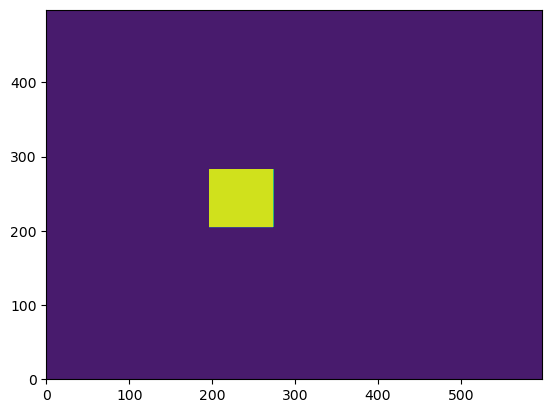

In [8]:
plt.contourf(csapr_mask)

## Compute column-maximum reflectivity

In [15]:
def compute_col_max_ref(wrf_ref_file):
    ds_ref = xr.open_dataset(wrf_ref_file)
    ref = ds_ref['REFL_10CM']
    ref_coords = ref.coords
    lon = ds_ref['XLONG']
    lat = ds_ref['XLAT']
    zamsl = ds_ref['ZAMSL']
    ref_attrs = ref.attrs
    lon_attrs = lon.attrs
    lat_attrs = lat.attrs
    zamsl_attrs = zamsl.attrs
    ds_ref.close()
    

    # Compute column max reflectivity
    col_max_ref = np.nanmax(ref, axis=0)

    # Mask where col_max_ref is <= -35
    valid_mask = col_max_ref > -35

    # Initialize col_max_ref_arg with NaNs
    col_max_ref_arg = np.full(ref.shape[1:], np.nan, dtype=float)

    if np.any(valid_mask):  # Only compute where there are valid values
        # Replace NaNs with -inf to prevent failures in nanargmax
        ref_filled = np.where(np.isnan(ref), -np.inf, ref)

        # Compute indices safely
        valid_indices = np.nanargmax(ref_filled, axis=0)

        # Assign indices only where col_max_ref > -35
        col_max_ref_arg[valid_mask] = valid_indices[valid_mask]


    ref_dict = {'col_max_ref':col_max_ref,
                'col_max_ref_arg':col_max_ref_arg,
                'ref':ref,
                'lat':lat,
                'lon':lon,
                'zamsl':zamsl,
                'ref_attrs':ref_attrs,
                'lon_attrs':lon_attrs,
                'lat_attrs':lat_attrs,
                'zamsl':zamsl,
               }
    return ref_dict


## Compute IR Tb from OLR using Yang and Slingo (2001) formula

In [16]:
def convert_OLR_to_IR_Tb(olr):
    # Convert OLR to an IR Tb using Yang and Slingo (2001)
    a = 1.2298
    b = -1.106e-3 # K^-1
    sigma = 5.67e-8 # W/m2/K4
    Tf = (olr/sigma)**0.25
    ir_tb = (-a + np.sqrt(a**2 + 4*b*Tf))/(2*b)
    return ir_tb

## Grab variables from 2D files

In [17]:
def get_2d_vars(wrf_2d_file,wrf_ref_file,ref_dict):
    lon_ref = ref_dict['lon']
    lat_ref = ref_dict['lat']
    
    ds_2d = xr.open_dataset(wrf_2d_file)
    #ds_2d = xr.open_dataset(wrf_2d_files[1500])
    olr = ds_2d['CAC_LWUPT'].squeeze()
    lwp = ds_2d['CAC_LWP'].squeeze()
    iwp = ds_2d['CAC_IWP'].squeeze()
    lon_2d = ds_2d['CAC_LONG'].squeeze()
    lat_2d = ds_2d['CAC_LAT'].squeeze()
    ds_2d.close()
    olr_attrs = olr.attrs
    lwp_attrs = lwp.attrs
    iwp_attrs = iwp.attrs
    lon_attrs = lon_2d.attrs
    lat_attrs = lat_2d.attrs
    
    
    #----------------------------------------------------------
    # Create CSAPR mask to limit horizontal domain. Also use CSAPR data
    # to NaN out values lying outside the radial max
    #----------------------------------------------------------
    csapr_mask = get_csapr_mask(wrf_ref_file,wrf_2d_file)
    #csapr_mask = get_csapr_mask(wrf_ref_files[1500],wrf_2d_files[1500])
    ref_id = np.where(np.isnan(ref_dict['col_max_ref']))
    
    olr = subset_var(olr,csapr_mask)
    olr[ref_id] = np.nan
    lwp = subset_var(lwp,csapr_mask)
    lwp[ref_id] = np.nan
    iwp = subset_var(iwp,csapr_mask)
    iwp[ref_id] = np.nan
    twp = lwp + iwp
    ir_tb = convert_OLR_to_IR_Tb(olr)
    
    x2d_dict = {'olr':olr,
                'lwp':lwp,
                'iwp':iwp,
                'twp':twp,
                'ir_tb':ir_tb,
                'lon':ref_dict['lon'],
                'lat':ref_dict['lat'],
                'olr_attrs':olr_attrs,
                'lwp_attrs':lwp_attrs,
                'iwp_attrs':iwp_attrs,
                'lon_attrs':lon_attrs,
                'lat_attrs':lat_attrs,
                'ref_id':ref_id,
               }
    
    return x2d_dict

## Calculate CTT using condensate threshold

In [18]:
def calc_ctt(temp,height,qt,cloud_mask,nx_2d,ny_2d):
    
    ctt = np.zeros((ny_2d,nx_2d))-999.
    cth = np.zeros((ny_2d,nx_2d))-999.

    for iii in range(nx_2d):
        for jjj in range(ny_2d):
            sc_temp = np.flip(temp[:,jjj,iii])
            sc_height = np.flip(height[:,jjj,iii])
            sc_qt = np.flip(qt[:,jjj,iii])
            sc_cloud_mask = np.flip(cloud_mask[:,jjj,iii])
            orig_sc_cloud_mask = np.flip(cloud_mask[:,jjj,iii])
            dumid = np.where(sc_cloud_mask > 0.)
            
            if (np.max(sc_cloud_mask) == 0.) or (np.size(dumid) <= 2.):
                continue
            else:
                labeled_array, num_features = ndimage.label(sc_cloud_mask)
                unique_ids = np.unique(labeled_array)[1:]
                
                for kk in range(num_features):
                    dumid = np.where(labeled_array == unique_ids[kk])
                    tmp_segment_size = np.size(dumid)
                    if tmp_segment_size == 1.:
                        dumid = dumid[0][0]
                        sc_cloud_mask[labeled_array == unique_ids[kk]] = 0
                    
                labeled_array, num_features = ndimage.label(sc_cloud_mask)
                if num_features > 0.:
                    unique_ids = np.unique(labeled_array)[1:]
                    ct_id = np.where(labeled_array > 0)[0][0]
                    ctt[jjj,iii] = sc_temp[ct_id]
                    cth[jjj,iii] = sc_height[ct_id]
                else:
                    pass

    ctt[ctt == -999.] = np.nan
    cth[cth == -999.] = np.nan

    return ctt,cth

## Get terrain height

In [19]:
def get_terrain_height(csapr_mask):
    ter_path = '/global/cfs/projectdirs/m1657/avarble/cacti/wrf/output/2019-05-01/'
    ter_file = ter_path+'wrfout_d01_2019-05-01_00:00:00'
    ds_ter = xr.open_dataset(ter_file,engine='netcdf4')
    ter_hgt = ds_ter['HGT'].squeeze()
    ds_ter.close()
    ter_hgt = subset_var(ter_hgt,csapr_mask)

    return ter_hgt

## Calculate effective radius in a manner faithful to Thompson AA microphysics scheme

In [20]:
def calc_effectRad(t1d, p1d, qv1d, qc1d, nc1d, qi1d, ni1d, qs1d, 
                   re_qc1d, re_qi1d, re_qs1d, kts, kte, is_aerosol_aware=True):

    # Constants
    R1 = 1.E-12
    R2 = 1.E-6
    rho_w = 1000.0
    rho_s = 100.0
    rho_i = 890.0
    am_r = np.pi * rho_w / 6.0
    am_i = np.pi * rho_i / 6.0
    am_s = 0.069
    bm_r = 3.0
    bm_i = 3.0
    bm_s = 2.0
    oams = 1./am_s
    bv_s = 0.55
    mu_s = 0.635
    
    # Sa and Sb arrays (for snow moments conversions)
    sa = np.array([5.065339, -0.062659, -3.032362, 0.029469, -0.000285, 
                   0.31255,   0.000204,  0.003199, 0.0,      -0.015952])
    sb = np.array([0.476221, -0.015896,  0.165977, 0.007468, -0.000141, 
                   0.060366,  0.000079,  0.000594, 0.0,      -0.003577])
    
    # G ratio for interpolation
    g_ratio = np.array([24,60,120,210,336,504,720,990,1320,1716,2184,2730,3360,4080,4896])
    
    # Define cse array based on the original Fortran code
    cse = np.zeros(17)
    cse[0] = bm_s + 1.0
    cse[1] = bm_s + 2.0
    cse[2] = bm_s * 2.0
    cse[3] = bm_s + bv_s + 1.0
    cse[4] = bm_s * 2.0 + bv_s + 1.0
    cse[5] = bm_s * 2.0 + 1.0
    cse[6] = bm_s + mu_s + 1.0
    cse[7] = bm_s + mu_s + 2.0
    cse[8] = bm_s + mu_s + 3.0
    cse[9] = bm_s + mu_s + bv_s + 1.0
    cse[10] = bm_s * 2.0 + mu_s + bv_s + 1.0
    cse[11] = bm_s * 2.0 + mu_s + 1.0
    cse[12] = bv_s + 2.0
    cse[13] = bm_s + bv_s
    cse[14] = mu_s + 1.0
    cse[15] = 1.0 + (1.0 + bv_s) / 2.0
    cse[16] = bm_s + bv_s + 2.0


    
    # Initializations
    rho = np.zeros_like(t1d)
    rc = np.zeros_like(t1d)
    nc = np.zeros_like(t1d)
    ri = np.zeros_like(t1d)
    ni = np.zeros_like(t1d)
    rs = np.zeros_like(t1d)
    
    has_qc = False
    has_qi = False
    has_qs = False

    re_qc1d[:] = 2.51E-6  # Default values
    re_qi1d[:] = 2.51E-6  # Default values
    re_qs1d[:] = 5.01E-6  # Default values

    # Compute radii and check conditions
    for k in range(kts-1, kte):  # Python indexing is 0-based, so adjust indices
        rho[k] = 0.622 * p1d[k] / (287.04 * t1d[k] * (qv1d[k] + 0.622))  # R is 287.04 J/(kg*K)
        rc[k] = max(R1, qc1d[k] * rho[k])
        nc[k] = max(2.0, min(nc1d[k] * rho[k], 1000.0))
        if not is_aerosol_aware:
            nc[k] = 200.0  # Default value for non-aerosol-aware
        if rc[k] > R1 and nc[k] > R2:
            has_qc = True

        ri[k] = max(R1, qi1d[k] * rho[k])
        ni[k] = max(R2, ni1d[k] * rho[k])
        if ri[k] > R1 and ni[k] > R2:
            has_qi = True

        rs[k] = max(R1, qs1d[k] * rho[k])
        if rs[k] > R1:
            has_qs = True

    # Update effective radii based on conditions
    if has_qc:
        for k in range(kts-1, kte):
            if rc[k] <= R1 or nc[k] <= R2:
                re_qc1d[k] = np.nan
                continue
            inu_c = 15 if nc[k] < 100 else min(15, int(1000.0 / nc[k]) + 2)
            lamc = (nc[k] * am_r * g_ratio[inu_c-1] / rc[k])**(1.0/bm_r)
            re_qc1d[k] = max(2.51E-6, min(0.5 * (3.0 + inu_c) / lamc, 50.E-6))
    else:
        re_qc1d[:] = np.nan

    if has_qi:
        for k in range(kts-1, kte):
            if ri[k] <= R1 or ni[k] <= R2:
                re_qi1d[k] = np.nan
                continue
            lami = (am_i * 2.0 * ni[k] / ri[k])**(1.0/bm_i)
            re_qi1d[k] = max(2.51E-6, min(0.5 * (3.0 + 2.0) / lami, 125.E-6))
    else:
        re_qi1d[:] = np.nan

    # Compute re_qs1d if has_qs
    if has_qs:
        for k in range(kts-1, kte):  # Python indexing is 0-based, adjust accordingly
            if rs[k] <= R1:
                re_qs1d[k] = np.nan
                continue
            tc0 = min(-0.1, t1d[k] - 273.15)
            smob = rs[k] * oams

            if abs(bm_s - 2.0) < 1.e-3:
                smo2 = smob
            else:
                loga_ = sa[0] + sa[1] * tc0 + sa[2] * bm_s + sa[3] * tc0 * bm_s \
                        + sa[4] * tc0 ** 2 + sa[5] * bm_s ** 2 + sa[6] * tc0 ** 2 * bm_s \
                        + sa[7] * tc0 * bm_s ** 2 + sa[8] * tc0 ** 3 + sa[9] * bm_s ** 3
                a_ = 10.0 ** loga_
                b_ = sb[0] + sb[1] * tc0 + sb[2] * bm_s + sb[3] * tc0 * bm_s \
                        + sb[4] * tc0 ** 2 + sb[5] * bm_s ** 2 + sb[6] * tc0 ** 2 * bm_s \
                        + sb[7] * tc0 * bm_s ** 2 + sb[8] * tc0 ** 3 + sb[9] * bm_s ** 3
                smo2 = (smob / a_) ** (1. / b_)

            # Second part of the computation (using cse)
            loga_ = sa[0] + sa[1] * tc0 + sa[2] * cse[0] + sa[3] * tc0 * cse[0] \
                    + sa[4] * tc0 ** 2 + sa[5] * cse[0] ** 2 + sa[6] * tc0 ** 2 * cse[0] \
                    + sa[7] * tc0 * cse[0] ** 2 + sa[8] * tc0 ** 3 + sa[9] * cse[0] ** 3
            a_ = 10.0 ** loga_
            b_ = sb[0] + sb[1] * tc0 + sb[2] * cse[0] + sb[3] * tc0 * cse[0] \
                    + sb[4] * tc0 ** 2 + sb[5] * cse[0] ** 2 + sb[6] * tc0 ** 2 * cse[0] \
                    + sb[7] * tc0 * cse[0] ** 2 + sb[8] * tc0 ** 3 + sb[9] * cse[0] ** 3
            smoc = a_ * smo2 ** b_
            re_qs1d[k] = max(5.01E-6, min(0.5 * (smoc / smob), 999.E-6))
    else:
        re_qs1d[:] = np.nan


    # Example usage
    # You would call calc_effectRad with the proper input arrays and indices.
    return re_qc1d, re_qi1d, re_qs1d

# Compute layer thickness

In [21]:
def compute_dz(height):
    """Compute layer thickness (dz) from height midpoints."""
    height_mid = 0.5 * (height[:-1,:,:] + height[1:,:,:])
    dz = height_mid[1:,:,:] - height_mid[:-1,:,:]
    return dz

# Interpolate efficiencies from LUT to the provided Reff

In [22]:
def interp_Q(LUT, re_eff, hydro, wl):
    """Interpolate Q_scat and Q_abs from LUT for each grid point."""
    key = f"{hydro}_{wl}"
    qsca_lut = LUT[key]["qsca"]
    qabs_lut = LUT[key]["qabs"]
    radii_lut = LUT["radii"]
    # flatten for interpolation
    shape = re_eff.shape
    re_flat = re_eff.flatten()
    qsca = interp1d(radii_lut, qsca_lut, bounds_error=False, fill_value=(qsca_lut[0], qsca_lut[-1]))(re_flat)
    qabs = interp1d(radii_lut, qabs_lut, bounds_error=False, fill_value=(qabs_lut[0], qabs_lut[-1]))(re_flat)
    return qsca.reshape(shape), qabs.reshape(shape)

# Compute optical depth per hydrometeor

In [23]:
def compute_tau(q, r_eff, rho_hydro, dz, Q_scat, Q_abs):
    """Vectorized optical depth computation."""
    mask = ~np.isnan(r_eff)
    tau_scat = np.zeros_like(dz)
    tau_abs = np.zeros_like(dz)
    tau_scat[mask] = (3 * Q_scat[mask] * q[mask]) / (2 * rho_hydro * r_eff[mask]) * dz[mask]
    tau_abs[mask] = (3 * Q_abs[mask] * q[mask]) / (2 * rho_hydro * r_eff[mask]) * dz[mask]
    return tau_scat + tau_abs

# Compute optical depth considering all hydrometeors

In [24]:
def compute_all_tau(q_dict, r_eff_dict, dz, DENSITIES, LUT, weightings):
    """
    Compute optical depths for VIS, IR, and weighted combinations.
    """
    tau_VIS = np.zeros_like(dz)
    tau_IR = np.zeros_like(dz)
    
    for hydro in q_dict.keys():
        rho = DENSITIES[hydro]
        q = q_dict[hydro]
        r_eff = r_eff_dict[hydro]
        Q_scat_VIS, Q_abs_VIS = interp_Q(LUT, r_eff, hydro, "VIS")
        Q_scat_IR,  Q_abs_IR  = interp_Q(LUT, r_eff, hydro, "IR")
        tau_VIS += compute_tau(q, r_eff, rho, dz, Q_scat_VIS, Q_abs_VIS)
        tau_IR  += compute_tau(q, r_eff, rho, dz, Q_scat_IR, Q_abs_IR)
    
    tau_combined = {}
    for key, (w_VIS, w_IR) in weightings.items():
        tau_combined[key] = w_VIS*tau_VIS + w_IR*tau_IR
    
    return tau_VIS, tau_IR, tau_combined

# Compute CTT/CTH from cumulative optical depth (vectorized)

In [25]:
# ===========================
# Vectorized CTT/CTH from cumulative tau
# ===========================
def compute_ctt_cth_vectorized(tau_dict, temperature, height, tau_threshold=1.0):
    nz, ny, nx = temperature.shape
    temp_rev = temperature[::-1,:,:]
    height_rev = height[::-1,:,:]

    results = {}

    # VIS and IR
    for key in ['tau_VIS', 'tau_IR']:
        tau_rev = tau_dict[key][::-1,:,:]
        cum_tau = np.nancumsum(tau_rev, axis=0)
        exceed_idx = np.argmax(cum_tau > tau_threshold, axis=0)
        valid_mask = np.any(cum_tau > tau_threshold, axis=0)
        ctt = np.full((ny,nx), np.nan)
        cth = np.full((ny,nx), np.nan)
        rows, cols = np.where(valid_mask)
        ctt[rows,cols] = temp_rev[exceed_idx[rows,cols], rows, cols]
        cth[rows,cols] = height_rev[exceed_idx[rows,cols], rows, cols]
        results[f'ctt_{key}'] = ctt-273.15
        results[f'cth_{key}'] = cth*1.e-3

    # Weighted combinations
    for wkey, tau_comb in tau_dict['tau_combined'].items():
        tau_rev = tau_comb[::-1,:,:]
        cum_tau = np.nancumsum(tau_rev, axis=0)
        exceed_idx = np.argmax(cum_tau > tau_threshold, axis=0)
        valid_mask = np.any(cum_tau > tau_threshold, axis=0)
        ctt = np.full((ny,nx), np.nan)
        cth = np.full((ny,nx), np.nan)
        rows, cols = np.where(valid_mask)
        ctt[rows,cols] = temp_rev[exceed_idx[rows,cols], rows, cols]
        cth[rows,cols] = height_rev[exceed_idx[rows,cols], rows, cols]
        results[f'ctt_tau_{wkey}'] = ctt-273.15
        results[f'cth_tau_{wkey}'] = cth*1.e-3

    return results

In [26]:
def get_3d_vars(wrf_3d_file,wrf_2d_file,wrf_ref_file,ref_dict,x2d_dict):
    #=======================
    # Load 3D variables
    #=======================
    ds_3d = xr.open_dataset(wrf_3d_file)
    temp = ds_3d['CAC_T'].values.squeeze()-273.15 # deg C
    pressure = ds_3d['CAC_P'].values.squeeze() # Pa
    qc = ds_3d['CAC_QC'].values.squeeze() # g/kg
    qi = ds_3d['CAC_QI'].values.squeeze() # g/kg
    qs = ds_3d['CAC_QS'].values.squeeze() # g/kg
    qr = ds_3d['CAC_QR'].values.squeeze() # g/kg 
    qg = ds_3d['CAC_QG'].values.squeeze() # g/kg
    qv = ds_3d['CAC_QV'].values.squeeze() # g/kg
    nc = ds_3d['CAC_NC'].values.squeeze() # /kg
    ni = ds_3d['CAC_NI'].values.squeeze() # /kg
    nr = ds_3d['CAC_NR'].values.squeeze() # /kg
    ds_3d.close()

    #=======================
    # Subset to CSAPR domain
    #=======================
    csapr_mask = get_csapr_mask(wrf_ref_file,wrf_2d_file)
    ref_id = x2d_dict['ref_id']
    ter_hgt = get_terrain_height(csapr_mask)
    z = ref_dict['zamsl'].copy()
    z_agl = z.values - ter_hgt
    
    temp = subset_var_3d(temp,csapr_mask)
    qc = subset_var_3d(qc,csapr_mask)
    qr = subset_var_3d(qr,csapr_mask)
    qi = subset_var_3d(qi,csapr_mask)
    qs = subset_var_3d(qs,csapr_mask)
    qg = subset_var_3d(qg,csapr_mask)
    nc = subset_var_3d(nc,csapr_mask)
    ni = subset_var_3d(ni,csapr_mask)
    nr = subset_var_3d(nr,csapr_mask)
    qv = subset_var_3d(qv,csapr_mask)
    pressure = subset_var_3d(pressure,csapr_mask)
    
    #=======================
    # Air density
    #=======================
    Rd=287.04
    Tv = (temp+237.15)*(1. + 0.61*qv*(1.e-3))
    rho_air = pressure/(Rd*Tv)

    qt = qc + qi + qs # g/kg    
    nz,ny,nx = z.shape

    print('Computing CTT using condensate thresholds...')
    #--------------------------
    # Thresh 1 (Lenient)
    #--------------------------
    thresh = 1.e-6
    cloud_id = np.where(qt > thresh)
    
    if np.size(cloud_id) > 0.:
        cloud_mask = np.zeros([nz,ny,nx])
        cloud_mask[cloud_id] = 1.
        ctt_thresh_1,cth_thresh_1 = calc_ctt(temp,z_agl,qt,cloud_mask,nx,ny)
        ctt_thresh_1[ref_id] = np.nan
        cth_thresh_1[ref_id] = np.nan
    else:
        ctt_thresh_1 = np.zeros((ny,nx))
        cth_thresh_1 = np.zeros((ny,nx))
        ctt_thresh_1[:,:] = np.nan
        cth_thresh_1[:,:] = np.nan
    
    #--------------------------
    # Thresh 2 (Generous)
    #--------------------------
    thresh = 1.e-3
    cloud_id = np.where(qt > thresh)
    
    if np.size(cloud_id) > 0.:
        cloud_mask = np.zeros([nz,ny,nx])
        cloud_mask[cloud_id] = 1.
        ctt_thresh_2,cth_thresh_2 = calc_ctt(temp,z_agl,qt,cloud_mask,nx,ny)
        ctt_thresh_2[ref_id] = np.nan
        cth_thresh_2[ref_id] = np.nan
    else:
        ctt_thresh_2 = np.zeros((ny,nx))
        cth_thresh_2 = np.zeros((ny,nx))
        ctt_thresh_2[:,:] = np.nan
        cth_thresh_2[:,:] = np.nan
    
    #--------------------------
    # Thresh 3 (Robust)
    #--------------------------
    thresh = 1.e-1
    cloud_id = np.where(qt > thresh)
    
    if np.size(cloud_id) > 0.:
        cloud_mask = np.zeros([nz,ny,nx])
        cloud_mask[cloud_id] = 1.
        ctt_thresh_3,cth_thresh_3 = calc_ctt(temp,z_agl,qt,cloud_mask,nx,ny)
        ctt_thresh_3[ref_id] = np.nan
        cth_thresh_3[ref_id] = np.nan
    else:
        ctt_thresh_3 = np.zeros((ny,nx))
        cth_thresh_3 = np.zeros((ny,nx))
        ctt_thresh_3[:,:] = np.nan
        cth_thresh_3[:,:] = np.nan

    print('Computing effective radii...')
    #===================================================================================
    # Calculate the effective radius of cloud liquid water, cloud ice, and snow
    # This is entirely consistent with how the Thompson microphysics scheme does it
    #===================================================================================
    re_cloud = np.zeros((nz,ny,nx))
    re_ice = np.zeros((nz,ny,nx))
    re_snow = np.zeros((nz,ny,nx))
    
    for iii in range(nx):
        for jjj in range(ny):
            t1d = temp[:,jjj,iii]+273.15 # K
            p1d = pressure[:,jjj,iii] # Pa
            qv1d = qv[:,jjj,iii]*1.e-3 # kg/kg
            qc1d = qc[:,jjj,iii]*1.e-3 # kg/kg
            nc1d = nc[:,jjj,iii] # /kg
            qi1d = qi[:,jjj,iii]*1.e-3 # kg/kg
            ni1d = ni[:,jjj,iii] # /kg
            qs1d = qs[:,jjj,iii]*1.e-3 # kg/kg
            re_qc1d = np.zeros_like(qc1d)
            re_qi1d = np.zeros_like(qc1d)
            re_qs1d = np.zeros_like(qc1d)
            kts = 1
            kte = nz
            re_qc1d, re_qi1d, re_qs1d = calc_effectRad(t1d, p1d, qv1d, qc1d, nc1d, qi1d, ni1d, qs1d, 
                                           re_qc1d, re_qi1d, re_qs1d, kts, kte, is_aerosol_aware=True)
    
            re_cloud[:,jjj,iii] = re_qc1d
            re_ice[:,jjj,iii] = re_qi1d
            re_snow[:,jjj,iii] = re_qs1d
    


    out_dict = {'re_cloud':re_cloud,\
                're_ice':re_ice,\
                're_snow':re_snow,\
                'z_agl':z_agl,\
                'qc':qc,\
                'qi':qi,\
                'qs':qs,\
                'temp':temp,\
                'ctt_thresh_1':ctt_thresh_1,\
                'cth_thresh_1':cth_thresh_1*1.e-3,\
                'ctt_thresh_2':ctt_thresh_2,\
                'cth_thresh_2':cth_thresh_2*1.e-3,\
                'ctt_thresh_3':ctt_thresh_3,\
                'cth_thresh_3':cth_thresh_3*1.e-3,\
    }

    return out_dict

In [27]:
def compute_ctt_driver(in_dict,LUT,x2d_dict):

    re_cloud = in_dict['re_cloud'][1:-1,:,:]
    re_ice = in_dict['re_ice'][1:-1,:,:]
    re_snow = in_dict['re_snow'][1:-1,:,:]
    qc = in_dict['qc'][1:-1,:,:]
    qi = in_dict['qi'][1:-1,:,:]
    qs = in_dict['qs'][1:-1,:,:]
    temp = in_dict['temp']
    z_agl = in_dict['z_agl']
    ref_id = x2d_dict['ref_id']


    #=====================================================
    # Compute CTT using an optical depth thresholding technique
    #=====================================================
    # nx = 77; ny = 77; nz = 80
    # temp (temperature); dimensions: (nz,ny,nx); units: deg C 
    # rho_air (moist air density); dimensions: (nz,ny,nz); units: kg/m^3
    # z_agl (height above ground level); dimensions: (nz,ny,nx); units: m
    # qc (cloud water mass mixing ratio); dimensions: (nz,ny,nx); units: g/kg
    # qi (cloud ice mass mixing ratio); dimensions: (nz,ny,nx); units: g/kg
    # qs (snow mass mixing ratio); dimensions: (nz,ny,nx); units: g/kg
    # re_cloud (cloud water effective radius); dimensions: (nz,ny,nx); units: m
    # re_ice (cloud ice effective radius); dimensions: (nz,ny,nx); units: m
    # re_snow (cloud snow effective radius); dimensions: (nz,ny,nx); units: m

    #=======================
    # Compute dz
    #=======================
    dz = compute_dz(z_agl)

    #=======================
    # Pack hydrometeor q's and r_eff for optical depth
    #=======================
    q_dict = {'cloud': qc*1e-3, 'ice': qi*1e-3, 'snow': qs*1e-3}  # kg/kg
    r_eff_dict = {'cloud': re_cloud, 'ice': re_ice, 'snow': re_snow} # meters

    #=======================
    # Hydrometeor densities
    #=======================
    DENSITIES = {'cloud': 1000.0, 'ice': 890.0, 'snow': 100.0}
    weightings = {
        '10_90': (0.1, 0.9),
        '30_70': (0.3, 0.7),
        '50_50': (0.5, 0.5),
        '70_30': (0.7, 0.3),
        '90_10': (0.9, 0.1)
    }

    #=======================
    # Compute optical depths using LUTs and weightings
    #=======================
    tau_VIS, tau_IR, tau_combined = compute_all_tau(q_dict, r_eff_dict, dz, 
                                                    DENSITIES=DENSITIES,
                                                    LUT=LUT,
                                                    weightings=weightings)

    tau_cum_dict = {}
    tau_cum_dict['tau_VIS'] = np.nansum(tau_VIS,axis=0)
    tau_cum_dict['tau_IR'] = np.nansum(tau_IR,axis=0)
    for key,val in tau_combined.items():
        tau_cum_dict['tau_'+key] = np.nansum(val,axis=0)
        
    #=======================
    # Compute cloud-top temperature/height from cumulative tau
    #=======================
    tau_dict_for_ctt = {"tau_VIS": tau_VIS, "tau_IR": tau_IR}
    #tau_dict_for_ctt.update(tau_combined)
    tau_dict_for_ctt['tau_combined'] = tau_combined

    
    ctt_cth_results = compute_ctt_cth_vectorized(tau_dict_for_ctt, temp[1:-1,:,:]+273.15, z_agl[1:-1,:,:], tau_threshold=1.0)


    # Apply csapr mask
    for key in ctt_cth_results.keys():
        ctt_cth_results[key][ref_id] = np.nan    

    for key in tau_cum_dict.keys():
        tau_cum_dict[key][ref_id] = np.nan

    return tau_cum_dict, ctt_cth_results  

In [28]:
def write_file(ref_dict,x2d_dict, x3d_dict, ctt_cth_dict,tau_cum_dict,out_datetime):
    out_dict = {'col_max_ref':ref_dict['col_max_ref'],
                'ir_tb':x2d_dict['ir_tb'],
                'lwp':x2d_dict['lwp'],
                'iwp':x2d_dict['iwp'],
                'twp':x2d_dict['twp'],
                'ctt_thresh_1':x3d_dict['ctt_thresh_1'],
                'ctt_thresh_2':x3d_dict['ctt_thresh_2'],
                'ctt_thresh_3':x3d_dict['ctt_thresh_3'],
                'cth_thresh_1':x3d_dict['cth_thresh_1'],
                'cth_thresh_2':x3d_dict['cth_thresh_2'],
                'cth_thresh_3':x3d_dict['cth_thresh_3'],
                'ctt_tau_vis':ctt_cth_dict['ctt_tau_VIS'],
                'cth_tau_vis':ctt_cth_dict['cth_tau_VIS'],
                'ctt_tau_ir':ctt_cth_dict['ctt_tau_IR'],
                'cth_tau_ir':ctt_cth_dict['cth_tau_IR'],
                'ctt_tau_10_90':ctt_cth_dict['ctt_tau_10_90'],
                'cth_tau_10_90':ctt_cth_dict['cth_tau_10_90'],
                'ctt_tau_30_70':ctt_cth_dict['ctt_tau_30_70'],
                'cth_tau_30_70':ctt_cth_dict['cth_tau_30_70'],
                'ctt_tau_50_50':ctt_cth_dict['ctt_tau_50_50'],
                'cth_tau_50_50':ctt_cth_dict['cth_tau_50_50'],
                'ctt_tau_70_30':ctt_cth_dict['ctt_tau_70_30'],
                'cth_tau_70_30':ctt_cth_dict['cth_tau_70_30'],
                'ctt_tau_90_10':ctt_cth_dict['ctt_tau_90_10'],
                'cth_tau_90_10':ctt_cth_dict['cth_tau_90_10'],
                'opd_vis':tau_cum_dict['tau_VIS'],
                'opd_ir':tau_cum_dict['tau_IR'],
                'opd_10_90':tau_cum_dict['tau_10_90'],
                'opd_30_70':tau_cum_dict['tau_30_70'],
                'opd_50_50':tau_cum_dict['tau_50_50'],
                'opd_70_30':tau_cum_dict['tau_70_30'],
                'opd_90_10':tau_cum_dict['tau_90_10'],
               }

    # Define variable attributes
    out_dict_attrs = {
                'col_max_ref': {
                    'long_name': 'Column-Maximum Radar Reflectivity',
                    'units': 'dBZ',
                },
                'ir_tb':{
                    'long_name': 'Infrared Brightness Temperature derived from OLR',
                    'units':'K'
                },
                'twp':{
                    'long_name': 'Total Water Path',
                    'units':'g/m2'
                },
                'lwp':{
                    'long_name': 'Liquid Water Path',
                    'units':'g/m2'
                },
                'iwp':{
                    'long_name': 'Ice Water Path',
                    'units':'g/m2'
                },
                'opd_vis':{
                    'long_name': 'Visibile Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Corresponds to the visible wavelength of GOES-16 (0.64 um)',
                    'description_3':'The visible wavelength means that the scattering coefficient >> absorption coefficient in calculations',
                },
                'opd_ir':{
                    'long_name': 'Infrared Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Corresponds to the infrared (IR) wavelength of GOES-16 (11.2 um)',
                    'description_3':'The IR wavelength means that the scattering coefficient << absorption coefficient in calculations',
                },
                'opd_10_90':{
                    'long_name': 'Weighted (VIS:IR 10:90) Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Weighted between opd_vis and opd_ir in a 10:90 VIS:IR weighting',
                },
                'opd_30_70':{
                    'long_name': 'Weighted (VIS:IR 30:70) Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Weighted between opd_vis and opd_ir in a 30:70 VIS:IR weighting',
                },
                'opd_50_50':{
                    'long_name': 'Weighted (VIS:IR 50:50) Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Weighted between opd_vis and opd_ir in a 50:50 VIS:IR weighting',
                },
                'opd_70_30':{
                    'long_name': 'Weighted (VIS:IR 70:30) Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Weighted between opd_vis and opd_ir in a 70:30 VIS:IR weighting',
                },
                'opd_90_10':{
                    'long_name': 'Weighted (VIS:IR 90:10) Optical Depth',
                    'units':'Dimensionless',
                    'description_1':'Optical depth calculated using cloud liquid water, cloud ice, and snow',
                    'description_2':'Weighted between opd_vis and opd_ir in a 90:10 VIS:IR weighting',
                },
                'ctt_tau_vis':{
                    'long_name': 'Cloud Top Temperature (using VIS optical depth)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed from the VIS optical depth only (opd_vis)',
                },
                'ctt_tau_ir':{
                    'long_name': 'Cloud Top Temperature (using IR optical depth)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed from the IR optical depth only (opd_ir)',
                },
                'cth_tau_vis':{
                    'long_name': 'Cloud Top Height (using VIS optical depth)',
                    'units':'kilometers',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed from the VIS optical depth only (opd_vis)',
                    'description_3':'Height is altitude above ground level',
                },
                'cth_tau_ir':{
                    'long_name': 'Cloud Top Height (using IR optical depth)',
                    'units':'kilometers',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed from the IR optical depth only (opd_ir)',
                    'description_3':'Height is altitude above ground level',
                },
                'ctt_tau_10_90':{
                    'long_name': 'Cloud Top Temperature (using VIS-IR combined optical depth with a 10:90 VIS:IR weighting)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_10_90',
                },
                'ctt_tau_30_70':{
                    'long_name': 'Cloud Top Temperature (using VIS-IR combined optical depth with a 30:70 VIS:IR weighting)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_30_70',
                },
                'ctt_tau_50_50':{
                    'long_name': 'Cloud Top Temperature (using VIS-IR combined optical depth with a 50:50 VIS:IR weighting)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_50_50',
                },
                'ctt_tau_70_30':{
                    'long_name': 'Cloud Top Temperature (using VIS-IR combined optical depth with a 70:30 VIS:IR weighting)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_70_30',
                },
                'ctt_tau_90_10':{
                    'long_name': 'Cloud Top Temperature (using VIS-IR combined optical depth with a 90:10 VIS:IR weighting)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top temperature calculated as the temperature (height) from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_90_10',
                },
                'cth_tau_10_90':{
                    'long_name': 'Cloud Top Height (using VIS-IR combined optical depth with a 10:90 VIS:IR weighting)',
                    'units':'meters',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_10_90',
                    'description_3':'Height is altitude above ground level',
                },
                'cth_tau_30_70':{
                    'long_name': 'Cloud Top Height (using VIS-IR combined optical depth with a 30:70 VIS:IR weighting)',
                    'units':'meters',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_30_70',
                    'description_3':'Height is altitude above ground level',
                },
                'cth_tau_50_50':{
                    'long_name': 'Cloud Top Height (using VIS-IR combined optical depth with a 50:50 VIS:IR weighting)',
                    'units':'meters',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_50_50',
                    'description_3':'Height is altitude above ground level',
                },
                'cth_tau_70_30':{
                    'long_name': 'Cloud Top Height (using VIS-IR combined optical depth with a 70:30 VIS:IR weighting)',
                    'units':'meters',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_70_30',
                    'description_3':'Height is altitude above ground level',
                },
                'cth_tau_90_10':{
                    'long_name': 'Cloud Top Height (using VIS-IR combined optical depth with a 90:10 VIS:IR weighting)',
                    'units':'meters',
                    'description_1':'Cloud top height calculated as the height from domain top downwards where cumulative optical depth exceeds a value of 1',
                    'description_2':'Cumulative optical depth is computed using opd_90_10',
                    'description_3':'Height is altitude above ground level',
                },
                'ctt_thresh_1':{
                    'long_name': 'Cloud Top Temperature (lenient threshold)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top is defined using a total water mixing ratio of 1.e-6 g/kg',
                    'description_2':'Total water mixing ratio only considers cloud liquid water, cloud ice, and snow',
                    'description_3':'Cloud-top ID omits tenuous layers by requiring the layer to be at least 2 grid points thick',
                },
                'ctt_thresh_2':{
                    'long_name': 'Cloud Top Temperature (generous threshold)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top is defined using a total water mixing ratio of 1.e-3 g/kg',
                    'description_2':'Total water mixing ratio only considers cloud liquid water, cloud ice, and snow',
                    'description_3':'Cloud-top ID omits tenuous layers by requiring the layer to be at least 2 grid points thick',
                },
                'ctt_thresh_3':{
                    'long_name': 'Cloud Top Temperature (robust threshold)',
                    'units':'degrees Celsius',
                    'description_1':'Cloud top is defined using a total water mixing ratio of 1.e-1 g/kg',
                    'description_2':'Total water mixing ratio only considers cloud liquid water, cloud ice, and snow',
                    'description_3':'Cloud-top ID omits tenuous layers by requiring the layer to be at least 2 grid points thick',
                },
                'cth_thresh_1':{
                    'long_name': 'Cloud Top Height (lenient threshold)',
                    'units':'km',
                    'description_1':'Cloud top is defined using a total water mixing ratio of 1.e-6 g/kg',
                    'description_2':'Total water mixing ratio only considers cloud liquid water, cloud ice, and snow',
                    'description_3':'Cloud-top ID omits tenuous layers by requiring the layer to be at least 2 grid points thick',
                },
                'cth_thresh_2':{
                    'long_name': 'Cloud Top Height (generous threshold)',
                    'units':'km',
                    'description_1':'Cloud top is defined using a total water mixing ratio of 1.e-3 g/kg',
                    'description_2':'Total water mixing ratio only considers cloud liquid water, cloud ice, and snow',
                    'description_3':'Cloud-top ID omits tenuous layers by requiring the layer to be at least 2 grid points thick',
                },
                'cth_thresh_3':{
                    'long_name': 'Cloud Top Height (robust threshold)',
                    'units':'km',
                    'description_1':'Cloud top is defined using a total water mixing ratio of 1.e-1 g/kg',
                    'description_2':'Total water mixing ratio only considers cloud liquid water, cloud ice, and snow',
                    'description_3':'Cloud-top ID omits tenuous layers by requiring the layer to be at least 2 grid points thick',
                },
    }   

    date_str = out_datetime.strftime('%Y%m%d_%H:%M:%S')
    # Output parameters
    output_path = '/pscratch/sd/m/mckenna/cacti/wrf/derived_3km/'
    output_filename = f'{output_path}WRF_CACTI_3km_derived_'+date_str+'.nc'

    # Define dimensions
    time_dimname = 'time'
    lon_dimname = 'west_east'
    lat_dimname = 'south_north'

    var_dict = {}
    # Define output variable dictionary
    for key, value in out_dict.items():
        if np.ndim(value) == 2.:
            var_dict[key] = ([lat_dimname,lon_dimname],value,out_dict_attrs[key])
            
    wrf_epoch = np.asarray([int(out_datetime.timestamp())])

    # Define coordinate attributes
    coord_attr_dict = {'time':{'long_name':'WRF Epoch time','units':'Epoch'},
                       'lon':{'long_name':'Longitude','units':'degrees'},
                       'lat':{'long_name':'Latitude','units':'degrees'},
                      }
    # Define coordinates
    coord_dict = {
            'time': ([time_dimname],wrf_epoch,coord_attr_dict['time']),
            'lon': ([lat_dimname,lon_dimname],ref_dict['lon'].values,coord_attr_dict['lon']),
            'lat': ([lat_dimname,lon_dimname],ref_dict['lat'].values,coord_attr_dict['lat']),
            }

    # Define global attributes
    gattr_dict = {
        'title':  'WRF derived 3-km variables for CACTI campaign (10-15-2018 - 03/03/2019)', \
        'Institution': 'Pacific Northwest National Laboratoy', \
        'Contact': 'McKenna Stanford, mckenna.stnaford@pnnl.gov', \
        'Created_on':  time.ctime(time.time()), \
        #'reflectivity_source_path': wrf_path, \
        #'2d_source_path': wrf_2d_path, \
        'Date': date_str, \
    }

    # Define xarray dataset
    dsout = xr.Dataset(var_dict, coords=coord_dict, attrs=gattr_dict)
    
    # Delete file if it already exists
    if os.path.isfile(output_filename):
        os.remove(output_filename)
    
    # Set encoding/compression for all variables
    comp = dict(zlib=True)
    encoding = {var: comp for var in dsout.data_vars}
    
    # Write to netcdf file
    dsout.to_netcdf(path=output_filename, mode="w",
                    format="NETCDF4", unlimited_dims=time_dimname, encoding=encoding)

    return output_filename

In [29]:
def driver_func(wrf_ref_file,wrf_2d_file,wrf_3d_file,wrf_ref_datetime,wrf_2d_datetime,wrf_3d_datetime,lut):
    ref_dict = compute_col_max_ref(wrf_ref_file)
    x2d_dict = get_2d_vars(wrf_2d_file,wrf_ref_file,ref_dict)
    x3d_dict = get_3d_vars(wrf_3d_file,wrf_2d_file,wrf_ref_file,ref_dict,x2d_dict)
    tau_cum_dict, ctt_cth_dict = compute_ctt_driver(x3d_dict,lut,x2d_dict)
    outfile_name = write_file(ref_dict, x2d_dict, x3d_dict, ctt_cth_dict, tau_cum_dict, wrf_ref_datetime)
    print('Completed file:',outfile_name)

# Serial execution

In [162]:
%%time
for ii in range(8199,len(wrf_ref_files)):
    ref_dict = compute_col_max_ref(wrf_ref_files[ii])
    x2d_dict = get_2d_vars(wrf_2d_files[ii], wrf_ref_files[ii], ref_dict)
    x3d_dict = get_3d_vars(wrf_3d_files[ii], wrf_2d_files[ii], wrf_ref_files[ii], ref_dict, x2d_dict)
    tau_cum_dict, ctt_cth_dict = compute_ctt_driver(x3d_dict,lut,x2d_dict)
    outfile_name = write_file(ref_dict, x2d_dict, x3d_dict, ctt_cth_dict, tau_cum_dict, wrf_ref_datetimes[ii])

    print(aaaaaa)

Computing CTT using condensate thresholds...
Computing effective radii...


NameError: name 'aaaaaa' is not defined

In [166]:
for ii in range(8199,len(wrf_ref_datetimes)):
    outfile_name = driver_func(wrf_ref_files[ii],wrf_2d_files[ii],wrf_3d_files[ii],wrf_ref_datetimes[ii],wrf_2d_datetimes[ii],wrf_3d_datetimes[ii],lut)
    print(aaaaaa)

Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20190208_18:00:00.nc


NameError: name 'aaaaaa' is not defined

# Parallel Exectuion

In [32]:
results = []
for ii in range(len(wrf_ref_datetimes)):
#for ii in range(8199,8203):
    result = dask.delayed(driver_func)(wrf_ref_files[ii],wrf_2d_files[ii],wrf_3d_files[ii],wrf_ref_datetimes[ii],wrf_2d_datetimes[ii],wrf_3d_datetimes[ii],lut)
    results.append(result)

In [33]:
# Trigger dask computation
final_result = dask.compute(*results)
wait(final_result)

/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/68824

Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20190127_05:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181118_20:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181026_17:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181031_15:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181029_18:45:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mcken

/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/68824

Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181030_19:45:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181126_22:45:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181209_21:15:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181015_20:15:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181113_10:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mcken

/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered


...

/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered
/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered


Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181128_20:45:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20190225_23:00:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181215_21:15:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181025_22:00:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20190302_14:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mcken

/tmp/ipykernel_2102752/688245480.py:16: RuntimeWarning: All-NaN axis encountered


Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181216_05:45:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181202_13:00:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20190227_18:30:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181021_11:00:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mckenna/cacti/wrf/derived_3km/WRF_CACTI_3km_derived_20181205_21:45:00.nc
Computing CTT using condensate thresholds...
Computing effective radii...
Completed file: /pscratch/sd/m/mcken

DoneAndNotDoneFutures(done=set(), not_done=set())

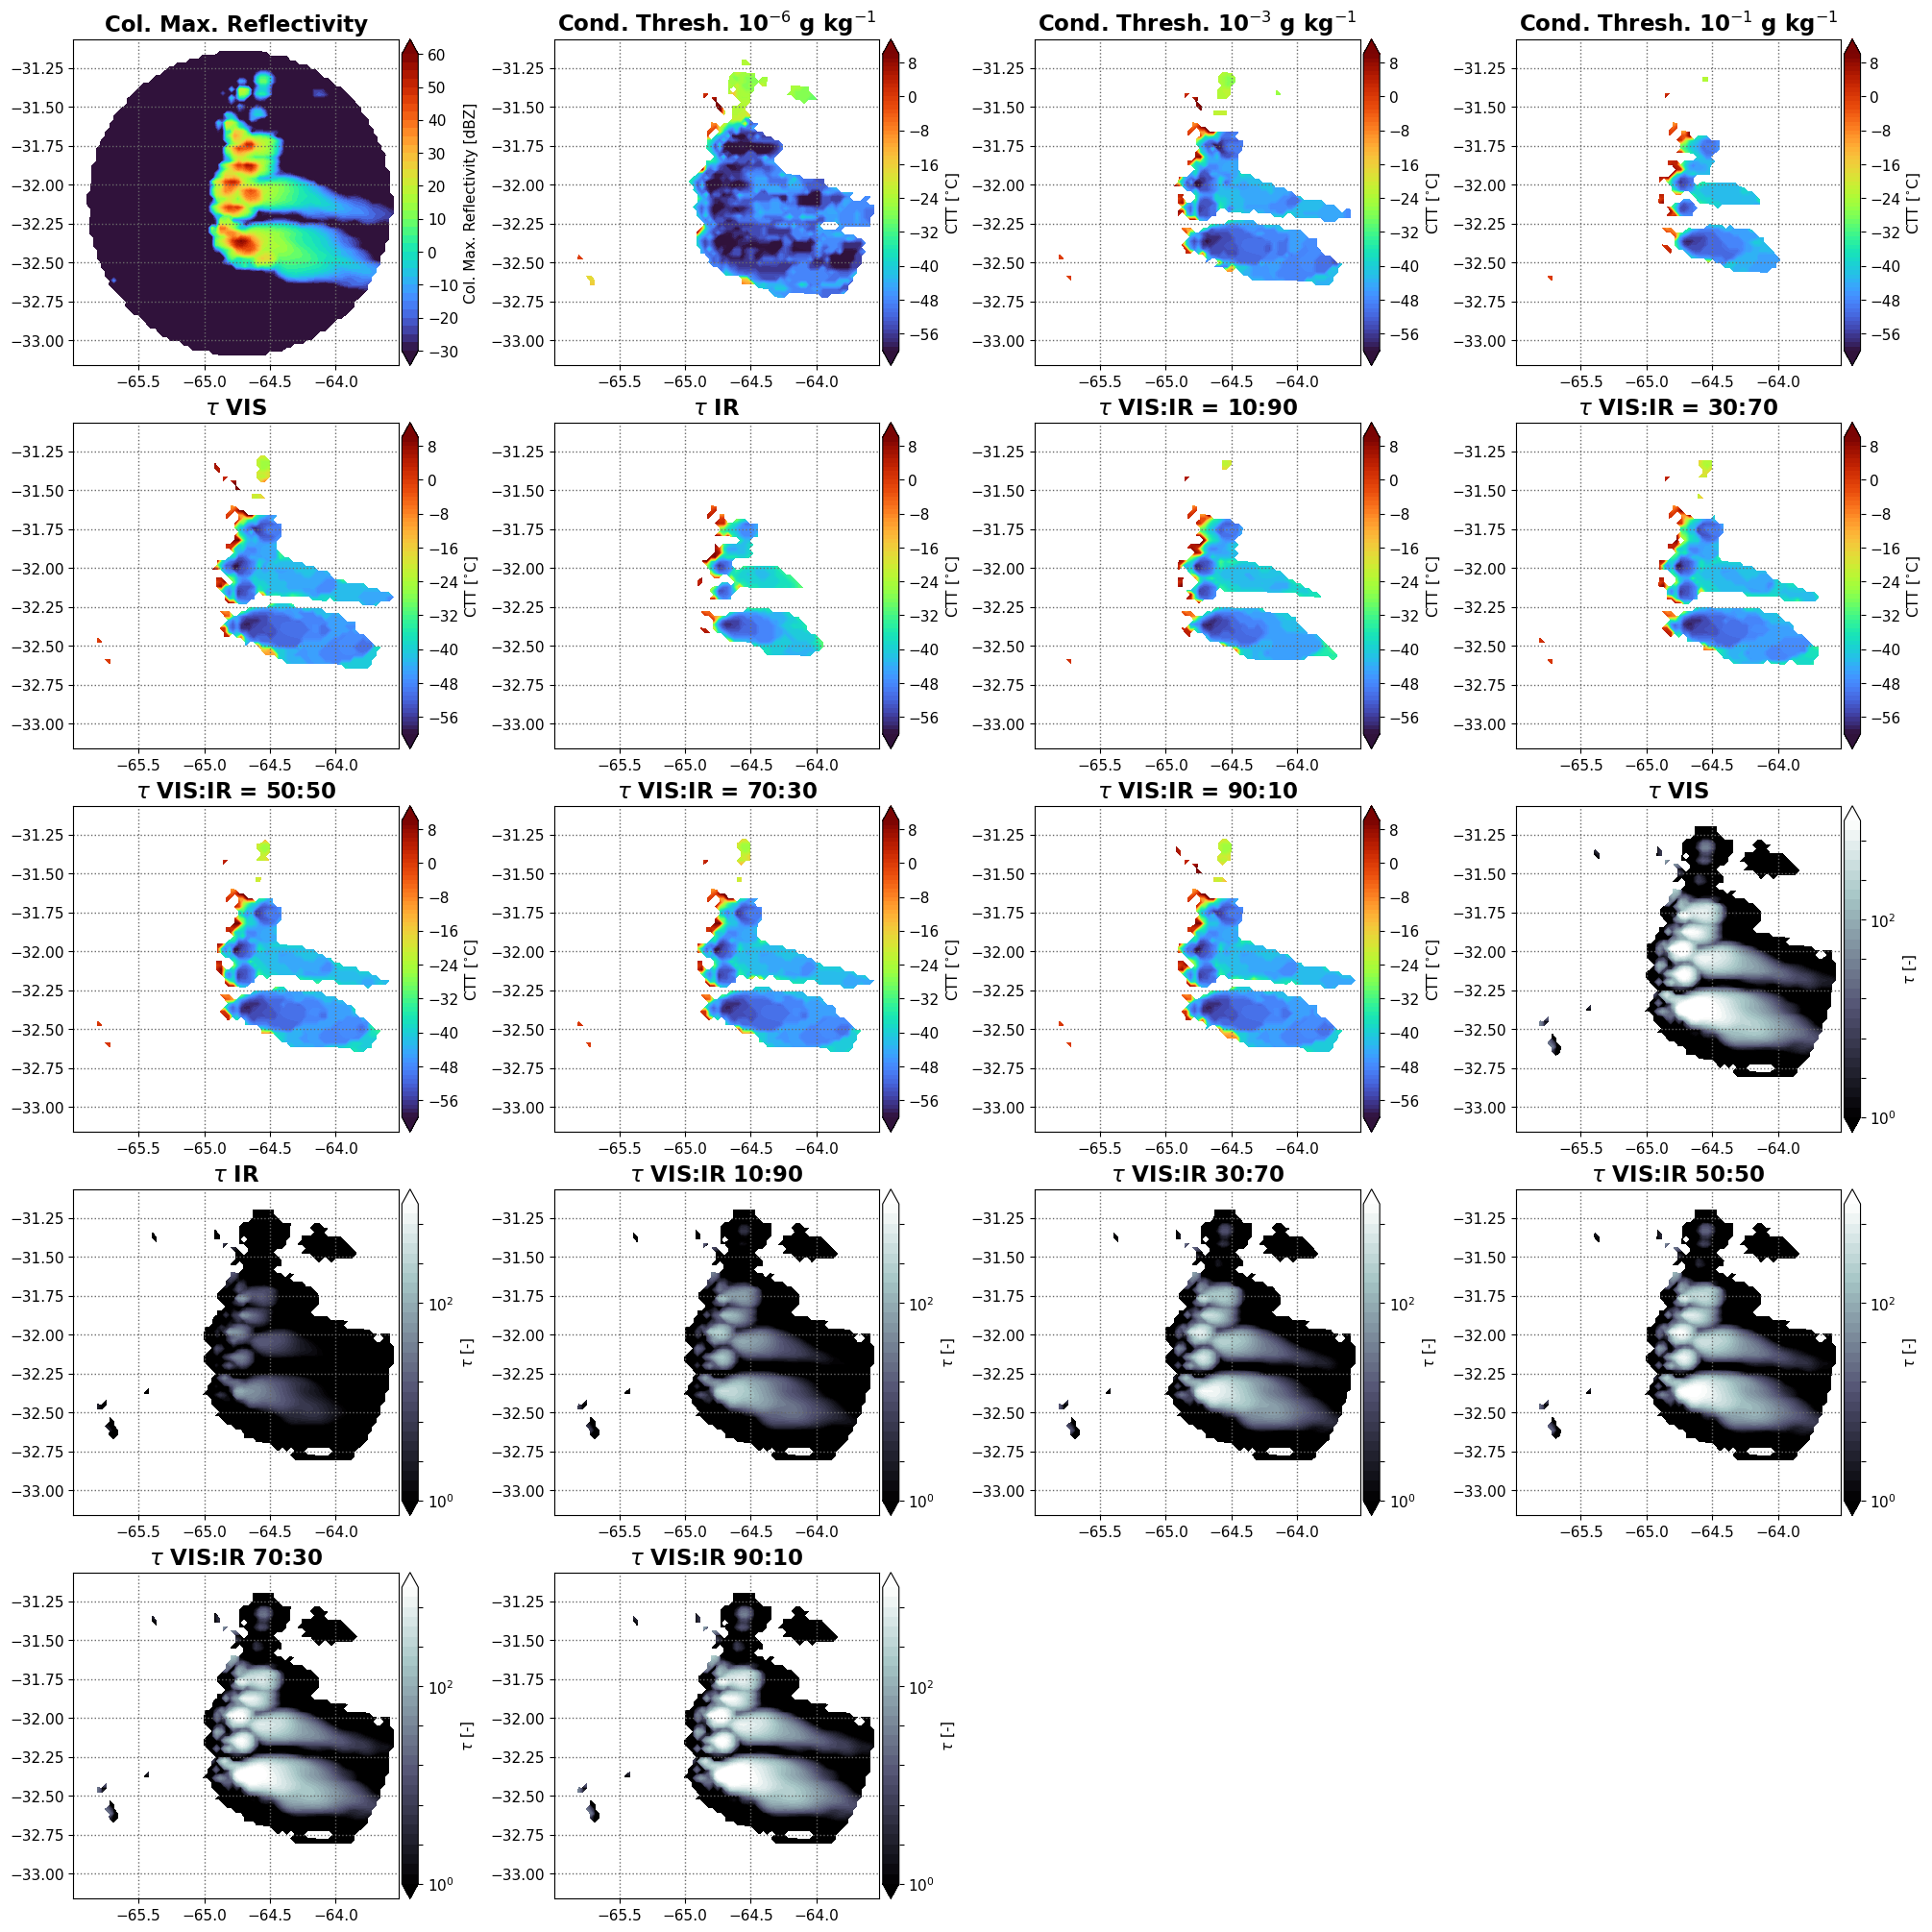

In [137]:
fig = plt.figure(figsize=(20,20),constrained_layout=True)
ax1 = fig.add_subplot(541)
ax2 = fig.add_subplot(542)
ax3 = fig.add_subplot(543)
ax4 = fig.add_subplot(544)
ax5 = fig.add_subplot(545)
ax6 = fig.add_subplot(546)
ax7 = fig.add_subplot(547)
ax8 = fig.add_subplot(548)
ax9 = fig.add_subplot(549)
ax10 = fig.add_subplot(5,4,10)
ax11 = fig.add_subplot(5,4,11)
ax12 = fig.add_subplot(5,4,12)
ax13 = fig.add_subplot(5,4,13)
ax14 = fig.add_subplot(5,4,14)
ax15 = fig.add_subplot(5,4,15)
ax16 = fig.add_subplot(5,4,16)
ax17 = fig.add_subplot(5,4,17)
ax18 = fig.add_subplot(5,4,18)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14,ax15,ax16,ax17,ax18]
Fontsize=11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')

tmpplot=ax1.contourf(ref_dict['lon'],ref_dict['lat'],ref_dict['col_max_ref'],levels=np.arange(-30,62.5,2.5),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Col. Max. Reflectivity [dBZ]',fontsize=Fontsize)
ax1.set_title('Col. Max. Reflectivity',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax2.contourf(ref_dict['lon'],ref_dict['lat'],x3d_dict['ctt_thresh_1'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax2.set_title('Cond. Thresh. 10$^{-6}$ g kg$^{-1}$',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax3.contourf(ref_dict['lon'],ref_dict['lat'],x3d_dict['ctt_thresh_2'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax3.set_title('Cond. Thresh. 10$^{-3}$ g kg$^{-1}$',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax4.contourf(ref_dict['lon'],ref_dict['lat'],x3d_dict['ctt_thresh_3'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax4.set_title('Cond. Thresh. 10$^{-1}$ g kg$^{-1}$',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax5.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_VIS'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax5.set_title('$\\tau$ VIS',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax6.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_IR'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax6.set_title('$\\tau$ IR',fontsize=Fontsize*1.5,fontweight='bold')


tmpplot=ax7.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_10_90'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax7.set_title('$\\tau$ VIS:IR = 10:90',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax8.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_30_70'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax8.set_title('$\\tau$ VIS:IR = 30:70',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax9.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_50_50'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax9.set_title('$\\tau$ VIS:IR = 50:50',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax10.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_70_30'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax10.set_title('$\\tau$ VIS:IR = 70:30',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax11.contourf(ref_dict['lon'],ref_dict['lat'],ctt_cth_dict['ctt_tau_90_10'],levels=np.arange(-60,11,1),cmap='turbo',extend='both')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
ax11.set_title('$\\tau$ VIS:IR = 90:10',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax12.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_VIS'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax12.set_title('$\\tau$ VIS',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax13.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_IR'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax13.set_title('$\\tau$ IR',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax14.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_10_90'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax14.set_title('$\\tau$ VIS:IR 10:90',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax15.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_30_70'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax15.set_title('$\\tau$ VIS:IR 30:70',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax16.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_50_50'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax16.set_title('$\\tau$ VIS:IR 50:50',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax17.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_70_30'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax17.set_title('$\\tau$ VIS:IR 70:30',fontsize=Fontsize*1.5,fontweight='bold')

tmpplot=ax18.contourf(ref_dict['lon'],ref_dict['lat'],tau_cum_dict['tau_90_10'],levels=10.**np.arange(0,3.1,0.1),cmap='bone',extend='both',norm=mpl.colors.LogNorm())
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('$\\tau$ [-]',fontsize=Fontsize)
ax18.set_title('$\\tau$ VIS:IR 90:10',fontsize=Fontsize*1.5,fontweight='bold')

plt.show()
plt.close()